In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calibration from Market Data

In [2]:
# ==============================
# Settings
# ==============================
ticker = "AAPL"
start_date = "2021-01-01"
end_date = "2026-01-01"  # End date is excluded. Therefore, 2026-01-01 is used to include data up to 2025-12-31.

trading_days_per_year = 252
delta_t = 1 / trading_days_per_year

csv_filename = "AAPL_2021_2025.csv"


# ==============================
# Download Apple price data
# ==============================
apple = yf.Ticker(ticker)

data = apple.history(
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True
)

if data.empty:
    raise ValueError(
        "No data were downloaded. Check the internet connection "
        "and the selected dates."
    )

# Keep the required columns
data = data[["Open", "High", "Low", "Close", "Volume"]].copy()

# Remove timezone information from the date index
if data.index.tz is not None:
    data.index = data.index.tz_localize(None)

# Sort observations by date
data = data.sort_index()

print("FIRST FIVE OBSERVATIONS")
print("-----------------------")
print(data.head())

print("\nLAST FIVE OBSERVATIONS")
print("----------------------")
print(data.tail())

print("\nNumber of trading days:", len(data))


# ==============================
# Save the downloaded data
# ==============================
data.to_csv(csv_filename)

print(f"\nData saved as {csv_filename}")


# ==============================
# Read the data from the CSV file
# ==============================
data = pd.read_csv(
    csv_filename,
    index_col="Date",
    parse_dates=True
)

# Sort the data again after reading the CSV file
data = data.sort_index()


# ==============================
# Check data quality
# ==============================
print("\nDATA QUALITY CHECKS")
print("-------------------")

print("Missing values:")
print(data.isna().sum())

number_of_duplicates = data.index.duplicated().sum()

print("\nDuplicate dates:")
print(number_of_duplicates)

print("\nDate range:")
print(data.index.min().date(), "to", data.index.max().date())

# Stop the program if closing prices are missing
if data["Close"].isna().any():
    raise ValueError(
        "Missing closing prices were found. "
        "The data must be checked before estimating the parameters."
    )

# Stop the program if duplicate dates are found
if number_of_duplicates > 0:
    raise ValueError(
        "Duplicate dates were found. "
        "The data must be checked before estimating the parameters."
    )


# ==============================
# Calculate daily log returns
# ==============================
data["Log_Return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

# The first return is missing because S_0 has no previous price
returns = data["Log_Return"].dropna()


# ==============================
# Estimate model parameters
# ==============================

# Sample mean of daily log returns
mean_daily_log_return = returns.mean()

# Sample standard deviation of daily log returns
# ddof=1 gives the sample standard deviation
std_daily_log_return = returns.std(ddof=1)

# Annualised volatility:
# sigma_hat = Std(R_i) / sqrt(delta_t)
sigma_hat = std_daily_log_return / np.sqrt(delta_t)

# Annual drift:
# mu_hat = mean(R_i) / delta_t + 0.5 * sigma_hat^2
mu_hat = (
    mean_daily_log_return / delta_t
    + 0.5 * sigma_hat**2
)

# The last observed historical price is S_n
S_n = data["Close"].iloc[-1]

# S_n becomes the initial value of the simulated process
S0_sim = S_n


# ==============================
# Display parameter estimates
# ==============================
print("\nBLACK-SCHOLES PARAMETER ESTIMATION")
print("----------------------------------")

print(f"Ticker: {ticker}")
print(
    f"First available date: "
    f"{data.index.min().date()}"
)
print(
    f"Last available date: "
    f"{data.index.max().date()}"
)

print(
    f"Number of price observations: "
    f"{len(data)}"
)
print(
    f"Number of return observations: "
    f"{len(returns)}"
)

print("\nDAILY LOG-RETURN STATISTICS")
print("---------------------------")

print(
    f"Mean daily log return: "
    f"{mean_daily_log_return:.8f}"
)

print(
    f"Sample standard deviation: "
    f"{std_daily_log_return:.8f}"
)

print("\nANNUALISED PARAMETER ESTIMATES")
print("------------------------------")

print(
    f"Estimated volatility (sigma_hat): "
    f"{sigma_hat:.6f}"
)

print(
    f"Estimated volatility: "
    f"{sigma_hat:.2%}"
)

print(
    f"Estimated drift (mu_hat): "
    f"{mu_hat:.6f}"
)

print(
    f"Estimated drift: "
    f"{mu_hat:.2%}"
)

print(
    f"Last observed historical price (S_n): "
    f"{S_n:.4f}"
)

print(
    f"Initial price for simulation (S0_sim): "
    f"{S0_sim:.4f}"
)


# ==============================
# Save the processed data
# ==============================
processed_filename = "AAPL_2021_2025_processed.csv"

data.to_csv(processed_filename)

print(
    f"\nProcessed data saved as "
    f"{processed_filename}"
)

FIRST FIVE OBSERVATIONS
-----------------------
                  Open        High         Low       Close     Volume
Date                                                                 
2021-01-04  129.734338  129.821783  123.166001  125.740868  143301900
2021-01-05  125.235547  128.004746  124.788583  127.295433   97664900
2021-01-06  124.098768  127.334355  122.796757  123.010521  155088000
2021-01-07  124.720602  127.897891  124.234778  127.208015  109578200
2021-01-08  128.675200  128.869542  126.537580  128.305984  105158200

LAST FIVE OBSERVATIONS
----------------------
                  Open        High         Low       Close    Volume
Date                                                                
2025-12-24  271.834940  274.919206  271.695216  273.302216  17910600
2025-12-26  273.651575  274.859323  272.353968  272.892975  21521800
2025-12-29  272.184327  273.851213  271.844961  273.252350  23715200
2025-12-30  272.304090  273.571723  271.775074  272.573578  22139600
2

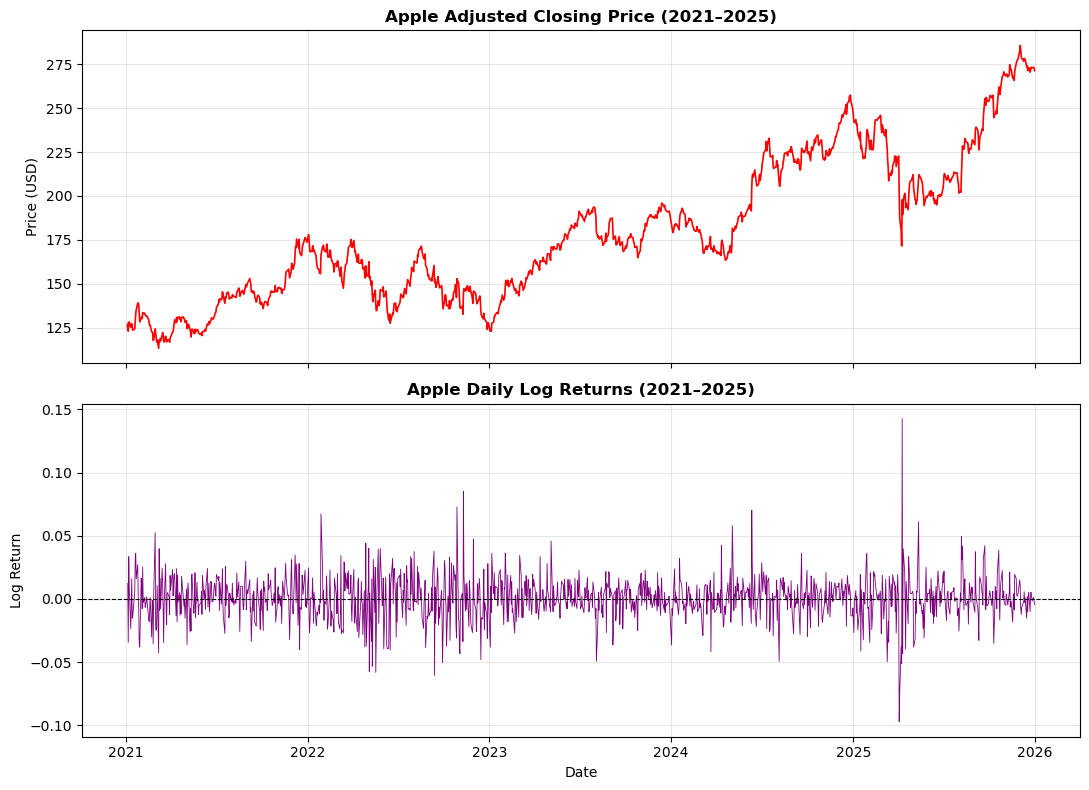

Figure saved as AAPL_price_and_log_returns.png


In [3]:
# ==============================
# Plot historical price and log returns
# ==============================
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

# Adjusted closing price
axes[0].plot(
    data.index,
    data["Close"],
    color="red",
    linewidth=1.2
)

axes[0].set_title(
    "Apple Adjusted Closing Price (2021–2025)",
    fontweight="bold"
)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(
    alpha=0.3
)

# Daily log returns
axes[1].plot(
    data.index,
    data["Log_Return"],
    color="purple",
    linewidth=0.6
)

axes[1].axhline(
    y=0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

axes[1].set_title(
    "Apple Daily Log Returns (2021–2025)",
    fontweight="bold"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Return")
axes[1].grid(
    alpha=0.3
)

fig.tight_layout()

# Save before plt.show()
figure_filename = "AAPL_price_and_log_returns.png"

fig.savefig(
    figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved as {figure_filename}")

# Step 2: Simulation of Brownian Motion

In [5]:
# ==============================
# Simulate future stock prices
# ==============================

# Simulation settings
T = 1
N = 252
delta_t_sim = T / N

number_of_paths = 10000


# Fix the random seed so that the results can be reproduced
random_seed = 42
rng = np.random.default_rng(random_seed)

# Simulation time points
time_grid = np.linspace(
    0,
    T,
    N + 1
)

# Generate independent standard normal variables
Z = rng.standard_normal(
    size=(N, number_of_paths)
)

# Daily continuously compounded stock returns
simulated_log_returns = (
    (mu_hat - 0.5 * sigma_hat**2) * delta_t_sim
    + sigma_hat * np.sqrt(delta_t_sim) * Z
)

# Create the simulated stock price array
simulated_prices = np.empty(
    (N + 1, number_of_paths)
)

# All paths start from the last observed historical price
simulated_prices[0, :] = S0_sim

# Construct each path using cumulative log returns
simulated_prices[1:, :] = (
    S0_sim
    * np.exp(
        np.cumsum(
            simulated_log_returns,
            axis=0
        )
    )
)

# Retain terminal stock prices
terminal_prices = simulated_prices[-1, :]


# ==============================
# Summary of simulation results
# ==============================

mean_terminal_price = terminal_prices.mean()
median_terminal_price = np.median(terminal_prices)
std_terminal_price = terminal_prices.std(ddof=1)

lower_terminal_price = np.percentile(
    terminal_prices,
    2.5
)

upper_terminal_price = np.percentile(
    terminal_prices,
    97.5
)

print("\nSTOCK PRICE SIMULATION")
print("----------------------")

print(f"Simulation horizon: {T} year")
print(f"Number of time steps: {N}")
print(f"Number of simulated paths: {number_of_paths}")
print(f"Random seed: {random_seed}")

print(
    f"\nInitial simulated price: "
    f"{S0_sim:.4f}"
)

print(
    f"Mean terminal price: "
    f"{mean_terminal_price:.4f}"
)

print(
    f"Median terminal price: "
    f"{median_terminal_price:.4f}"
)

print(
    f"Standard deviation of terminal prices: "
    f"{std_terminal_price:.4f}"
)

print(
    f"2.5th percentile: "
    f"{lower_terminal_price:.4f}"
)

print(
    f"97.5th percentile: "
    f"{upper_terminal_price:.4f}"
)





STOCK PRICE SIMULATION
----------------------
Simulation horizon: 1 year
Number of time steps: 252
Number of simulated paths: 10000
Random seed: 42

Initial simulated price: 271.3558
Mean terminal price: 330.0427
Median terminal price: 317.0801
Standard deviation of terminal prices: 93.6532
2.5th percentile: 182.6950
97.5th percentile: 548.1953


展示前20条路径（仅查看）

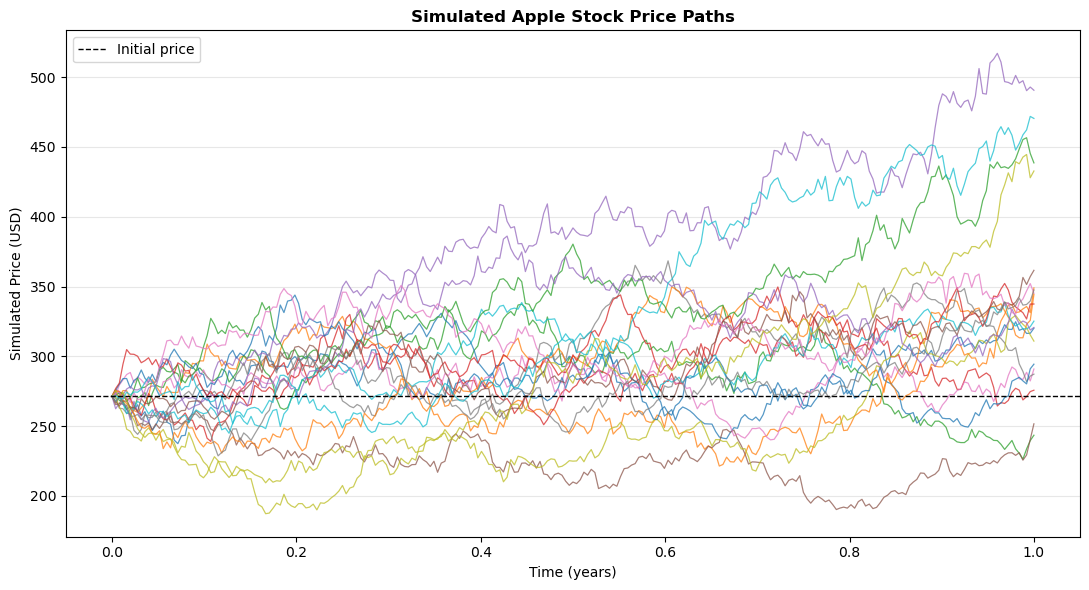


Simulation figure saved as AAPL_simulated_price_paths.png


In [6]:
# ==============================
# Plot selected simulated paths
# ==============================

number_of_displayed_paths = 20
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.plot(
    time_grid,
    simulated_prices[
        :,
        :number_of_displayed_paths
    ],
    linewidth=0.9,
    alpha=0.75
)

ax.axhline(
    y=S0_sim,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Initial price"
)

ax.set_title(
    "Simulated Apple Stock Price Paths",
    fontweight="bold"
)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Simulated Price (USD)")

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

fig.tight_layout()

simulation_figure_filename = (
    "AAPL_simulated_price_paths.png"
)

fig.savefig(
    simulation_figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nSimulation figure saved as "
    f"{simulation_figure_filename}"
)

# Step 3: Enlargement of Filtration

构造带噪声信息

In [8]:
# ==========================================
# Construction of noisy insider information
# ==========================================

# Recover the terminal Brownian motion values
# from the same standard normal variables used
# to simulate the stock price paths in Section 5.3
terminal_brownian_values = (
    np.sqrt(delta_t_sim)
    * np.sum(Z, axis=0)
)

# Noise levels considered in the experiment
noise_levels = np.array([
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
])

# Use a separate random generator for the signal noise
noise_random_seed = 2026
noise_rng = np.random.default_rng(
    noise_random_seed
)

# Generate one independent standard normal noise
# variable for each simulated path
xi = noise_rng.standard_normal(
    number_of_paths
)

# Store noisy signals and summary results
noisy_signals = {}
signal_results = []

print("\nTERMINAL BROWNIAN MOTION")
print("------------------------")
print(
    f"Sample mean of W_T: "
    f"{terminal_brownian_values.mean():.4f}"
)
print(
    f"Sample standard deviation of W_T: "
    f"{terminal_brownian_values.std(ddof=1):.4f}"
)

# Construct the signal for each noise level
for epsilon in noise_levels:

    signal = (
        terminal_brownian_values
        + epsilon * xi
    )

    noisy_signals[epsilon] = signal

    # Sample statistics
    sample_mean = signal.mean()

    sample_std = signal.std(
        ddof=1
    )

    sample_correlation = np.corrcoef(
        signal,
        terminal_brownian_values
    )[0, 1]

    # Theoretical values when T = 1
    theoretical_mean = 0.0

    theoretical_std = np.sqrt(
        1 + epsilon**2
    )

    theoretical_correlation = (
        1 / np.sqrt(1 + epsilon**2)
    )

    signal_results.append({
        "Noise level": epsilon,
        "Theoretical mean": theoretical_mean,
        "Sample mean": sample_mean,
        "Theoretical standard deviation":
            theoretical_std,
        "Sample standard deviation":
            sample_std,
        "Theoretical correlation":
            theoretical_correlation,
        "Sample correlation":
            sample_correlation
    })

# Convert the results into a table
signal_results_df = pd.DataFrame(
    signal_results
)

print("\nNOISY SIGNAL RESULTS")
print("--------------------")
print(
    signal_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)





TERMINAL BROWNIAN MOTION
------------------------
Sample mean of W_T: 0.0088
Sample standard deviation of W_T: 1.0032

NOISY SIGNAL RESULTS
--------------------
 Noise level  Theoretical mean  Sample mean  Theoretical standard deviation  Sample standard deviation  Theoretical correlation  Sample correlation
      0.0500            0.0000       0.0087                          1.0012                     1.0048                   0.9988              0.9987
      0.1000            0.0000       0.0086                          1.0050                     1.0088                   0.9950              0.9950
      0.2500            0.0000       0.0083                          1.0308                     1.0357                   0.9701              0.9701
      0.5000            0.0000       0.0078                          1.1180                     1.1249                   0.8944              0.8945
      1.0000            0.0000       0.0067                          1.4142                     1.

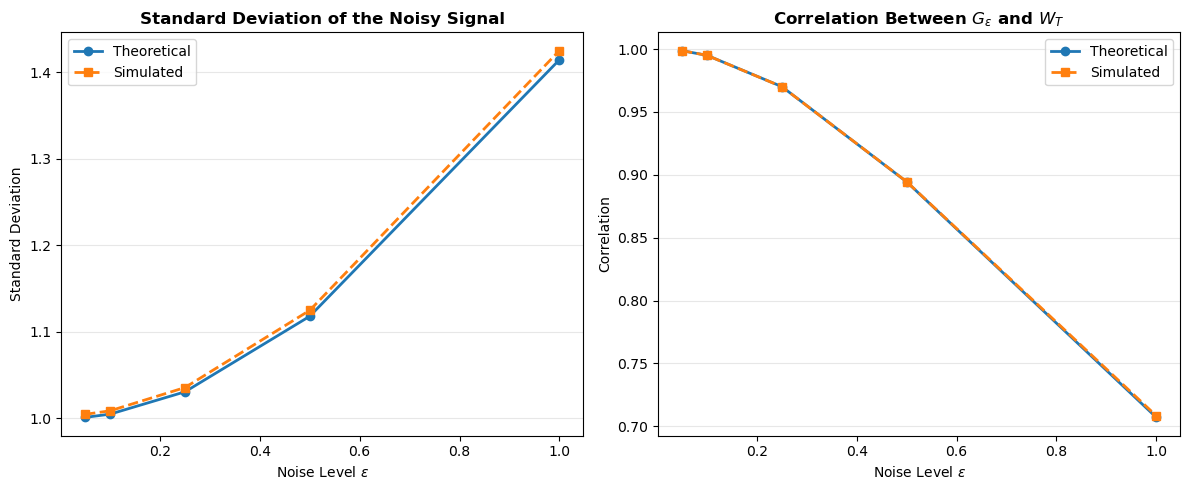


Noisy signal figure saved as AAPL_noisy_signal_comparison.png


In [9]:
# ==========================================
# Plot theoretical and sample results
# ==========================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Standard deviation comparison
axes[0].plot(
    noise_levels,
    signal_results_df[
        "Theoretical standard deviation"
    ],
    marker="o",
    linewidth=2,
    label="Theoretical"
)

axes[0].plot(
    noise_levels,
    signal_results_df[
        "Sample standard deviation"
    ],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Simulated"
)

axes[0].set_title(
    "Standard Deviation of the Noisy Signal",
    fontweight="bold"
)

axes[0].set_xlabel(
    r"Noise Level $\varepsilon$"
)

axes[0].set_ylabel(
    "Standard Deviation"
)

axes[0].grid(
    axis="y",
    alpha=0.3
)

axes[0].legend()


# Correlation comparison
axes[1].plot(
    noise_levels,
    signal_results_df[
        "Theoretical correlation"
    ],
    marker="o",
    linewidth=2,
    label="Theoretical"
)

axes[1].plot(
    noise_levels,
    signal_results_df[
        "Sample correlation"
    ],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Simulated"
)

axes[1].set_title(
    r"Correlation Between $G_\varepsilon$ and $W_T$",
    fontweight="bold"
)

axes[1].set_xlabel(
    r"Noise Level $\varepsilon$"
)

axes[1].set_ylabel(
    "Correlation"
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

axes[1].legend()

fig.tight_layout()

signal_figure_filename = (
    "AAPL_noisy_signal_comparison.png"
)

fig.savefig(
    signal_figure_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nNoisy signal figure saved as "
    f"{signal_figure_filename}"
)

# Step 4: Estimation of Conditional Expectations（没分开训练集和测试集）

In [10]:
# Construct Brownian motion paths from the same Z
# used in the stock price simulation
brownian_paths = np.zeros(
    (N + 1, number_of_paths)
)

brownian_paths[1:, :] = np.cumsum(
    np.sqrt(delta_t_sim) * Z,
    axis=0
)

terminal_brownian_values = brownian_paths[-1, :]

In [11]:
# ==================================================
# Monte Carlo regression for conditional expectations
# ==================================================

from sklearn.linear_model import LinearRegression

# Store the estimated conditional expectation paths
conditional_expectation_estimates = {}

# Store regression diagnostics
regression_results = []

for epsilon in noise_levels:

    signal = noisy_signals[epsilon]

    # One estimated m_t path for every simulated path
    estimated_m = np.empty(
        (N + 1, number_of_paths)
    )

    for time_index, t in enumerate(time_grid):

        current_brownian_values = (
            brownian_paths[time_index, :]
        )

        # Regressors:
        # W_t and G_epsilon
        regression_inputs = np.column_stack(
            (
                current_brownian_values,
                signal
            )
        )

        # Regression target:
        # W_T
        regression_target = (
            terminal_brownian_values
        )

        model = LinearRegression()

        model.fit(
            regression_inputs,
            regression_target
        )

        # Fitted values approximate
        # E[W_T | W_t, G_epsilon]
        estimated_m[time_index, :] = (
            model.predict(regression_inputs)
        )

        regression_results.append({
            "Time": t,
            "Noise level": epsilon,
            "Intercept": model.intercept_,
            "Coefficient on W_t":
                model.coef_[0],
            "Coefficient on G_epsilon":
                model.coef_[1],
            "R-squared":
                model.score(
                    regression_inputs,
                    regression_target
                )
        })

    conditional_expectation_estimates[
        epsilon
    ] = estimated_m


# Convert regression results into a table
regression_results_df = pd.DataFrame(
    regression_results
)

print(
    "\nMONTE CARLO REGRESSION RESULTS"
)
print(
    "------------------------------"
)

# Display selected observation times
selected_times = [
    0.00,
    0.25,
    0.50,
    0.75
]

selected_regression_results = (
    regression_results_df[
        regression_results_df["Time"].isin(
            selected_times
        )
    ]
)

print(
    selected_regression_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


MONTE CARLO REGRESSION RESULTS
------------------------------
  Time  Noise level  Intercept  Coefficient on W_t  Coefficient on G_epsilon  R-squared
0.0000       0.0500     0.0001              0.0000                    0.9972     0.9975
0.2500       0.0500     0.0001              0.0022                    0.9966     0.9975
0.5000       0.0500     0.0001              0.0044                    0.9950     0.9975
0.7500       0.0500     0.0001              0.0107                    0.9892     0.9975
0.0000       0.1000     0.0003              0.0000                    0.9895     0.9901
0.2500       0.1000     0.0004              0.0112                    0.9866     0.9901
0.5000       0.1000     0.0003              0.0187                    0.9802     0.9902
0.7500       0.1000     0.0002              0.0404                    0.9595     0.9904
0.0000       0.2500     0.0010              0.0000                    0.9397     0.9411
0.2500       0.2500     0.0016              0.0738       

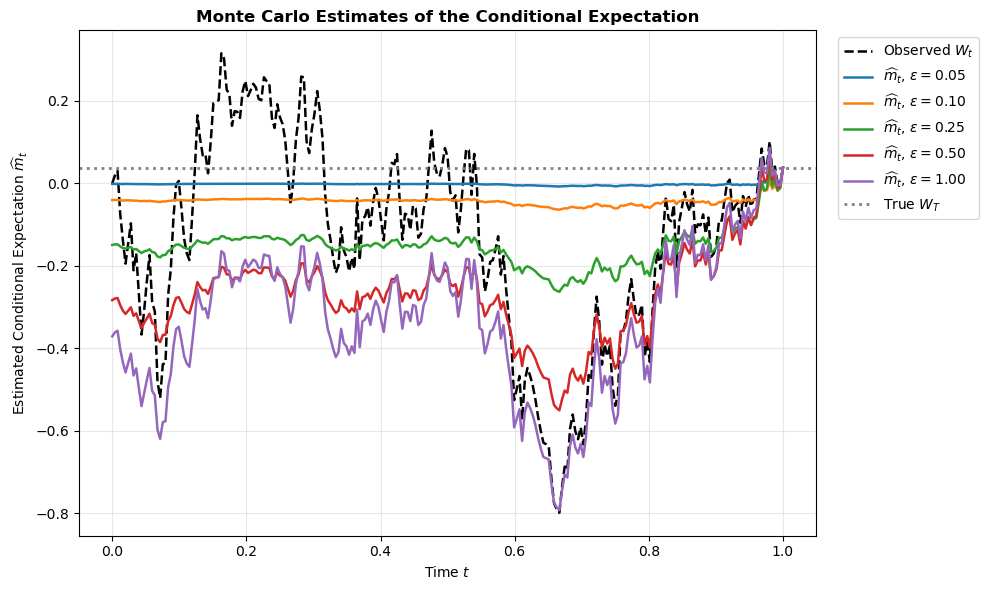


Conditional expectation figure saved as conditional_expectation_trajectories.png


In [12]:
# ==================================================
# Plot estimated conditional expectation trajectories
# ==================================================

representative_path = 0

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Plot the observed Brownian motion path
ax.plot(
    time_grid,
    brownian_paths[:, representative_path],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label=r"Observed $W_t$"
)

# Plot estimated m_t for each noise level
for epsilon in noise_levels:

    ax.plot(
        time_grid,
        conditional_expectation_estimates[
            epsilon
        ][:, representative_path],
        linewidth=1.8,
        label=(
            rf"$\widehat{{m}}_t$, "
            rf"$\varepsilon={epsilon:.2f}$"
        )
    )

# True terminal Brownian value
ax.axhline(
    terminal_brownian_values[
        representative_path
    ],
    color="grey",
    linestyle=":",
    linewidth=2,
    label=r"True $W_T$"
)

ax.set_title(
    "Monte Carlo Estimates of the Conditional Expectation",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Estimated Conditional Expectation "
    r"$\widehat{m}_t$"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

conditional_expectation_filename = (
    "conditional_expectation_trajectories.png"
)

fig.savefig(
    conditional_expectation_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nConditional expectation figure saved as "
    f"{conditional_expectation_filename}"
)

# Step 4: Estimation of Conditional Expectations

In [13]:
# Construct Brownian motion paths from the same Z
# used in the stock price simulation
brownian_paths = np.zeros(
    (N + 1, number_of_paths)
)

brownian_paths[1:, :] = np.cumsum(
    np.sqrt(delta_t_sim) * Z,
    axis=0
)

terminal_brownian_values = brownian_paths[-1, :]

In [14]:
# ==================================================
# Out-of-sample Monte Carlo regression
# ==================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Each index represents one complete Monte Carlo path
path_indices = np.arange(number_of_paths)

# Split complete paths into training and testing samples
training_indices, testing_indices = train_test_split(
    path_indices,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("\nMONTE CARLO SAMPLE SPLIT")
print("------------------------")
print(f"Training paths: {len(training_indices)}")
print(f"Testing paths: {len(testing_indices)}")


# Store conditional expectation estimates
conditional_expectation_estimates = {}

# Store the theoretical conditional expectations
theoretical_conditional_expectations = {}

# Store regression coefficients and diagnostics
regression_results = []


for epsilon in noise_levels:

    signal = noisy_signals[epsilon]

    # Store regression estimates for all paths
    estimated_m = np.empty(
        (N + 1, number_of_paths)
    )

    # Store theoretical values for comparison
    theoretical_m = np.empty(
        (N + 1, number_of_paths)
    )

    # Perform one cross-sectional regression
    # at each time before maturity
    for time_index, t in enumerate(time_grid[:-1]):

        current_brownian_values = (
            brownian_paths[time_index, :]
        )

        # Explanatory variables: W_t and G_epsilon
        regression_inputs = np.column_stack(
            (
                current_brownian_values,
                signal
            )
        )

        # Response variable: W_T
        regression_target = (
            terminal_brownian_values
        )

        model = LinearRegression()

        # Fit the model only on the training paths
        model.fit(
            regression_inputs[training_indices],
            regression_target[training_indices]
        )

        # Estimate m_t for all paths
        estimated_m[time_index, :] = model.predict(
            regression_inputs
        )

        # Theoretical conditional expectation
        signal_weight = (
            (T - t)
            / (T - t + epsilon**2)
        )

        theoretical_m[time_index, :] = (
            current_brownian_values
            + signal_weight
            * (
                signal
                - current_brownian_values
            )
        )

        # Theoretical regression coefficients
        theoretical_coefficient_W = (
            epsilon**2
            / (T - t + epsilon**2)
        )

        theoretical_coefficient_G = (
            (T - t)
            / (T - t + epsilon**2)
        )

        # In-sample R-squared
        training_r_squared = model.score(
            regression_inputs[training_indices],
            regression_target[training_indices]
        )

        # Out-of-sample R-squared
        testing_r_squared = model.score(
            regression_inputs[testing_indices],
            regression_target[testing_indices]
        )

        regression_results.append({
            "Time": t,
            "Noise level": epsilon,
            "Estimated intercept":
                model.intercept_,
            "Estimated coefficient on W_t":
                model.coef_[0],
            "Theoretical coefficient on W_t":
                theoretical_coefficient_W,
            "Estimated coefficient on G_epsilon":
                model.coef_[1],
            "Theoretical coefficient on G_epsilon":
                theoretical_coefficient_G,
            "Training R-squared":
                training_r_squared,
            "Testing R-squared":
                testing_r_squared
        })

    # At maturity, W_T is already observed
    estimated_m[-1, :] = terminal_brownian_values
    theoretical_m[-1, :] = terminal_brownian_values

    conditional_expectation_estimates[
        epsilon
    ] = estimated_m

    theoretical_conditional_expectations[
        epsilon
    ] = theoretical_m


regression_results_df = pd.DataFrame(
    regression_results
)


MONTE CARLO SAMPLE SPLIT
------------------------
Training paths: 8000
Testing paths: 2000


输出选定时刻的回归结果

In [15]:
# ==================================================
# Display results at selected times
# ==================================================

selected_time_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N)
]

selected_times = time_grid[
    selected_time_indices
]

selected_regression_results = (
    regression_results_df[
        np.isclose(
            regression_results_df["Time"].to_numpy()[:, None],
            selected_times,
            atol=1e-10
        ).any(axis=1)
    ]
    .copy()
)

print("\nSELECTED REGRESSION RESULTS")
print("---------------------------")

print(
    selected_regression_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


SELECTED REGRESSION RESULTS
---------------------------
  Time  Noise level  Estimated intercept  Estimated coefficient on W_t  Theoretical coefficient on W_t  Estimated coefficient on G_epsilon  Theoretical coefficient on G_epsilon  Training R-squared  Testing R-squared
0.0000       0.0500               0.0004                        0.0000                          0.0025                              0.9969                                0.9975              0.9975             0.9975
0.2500       0.0500               0.0004                        0.0030                          0.0033                              0.9961                                0.9967              0.9975             0.9975
0.5000       0.0500               0.0004                        0.0042                          0.0050                              0.9948                                0.9950              0.9975             0.9975
0.7500       0.0500               0.0004                        0.0106         

在 testing sample 上进行验证

In [16]:
# ==================================================
# Out-of-sample validation
# ==================================================

validation_results = []

for epsilon in noise_levels:

    estimated_m = (
        conditional_expectation_estimates[
            epsilon
        ]
    )

    theoretical_m = (
        theoretical_conditional_expectations[
            epsilon
        ]
    )

    for time_index in selected_time_indices:

        t = time_grid[time_index]

        regression_test_values = (
            estimated_m[
                time_index,
                testing_indices
            ]
        )

        theoretical_test_values = (
            theoretical_m[
                time_index,
                testing_indices
            ]
        )

        terminal_test_values = (
            terminal_brownian_values[
                testing_indices
            ]
        )

        current_test_values = (
            brownian_paths[
                time_index,
                testing_indices
            ]
        )

        # Difference between regression estimates
        # and the theoretical conditional expectation
        regression_theory_rmse = np.sqrt(
            np.mean(
                (
                    regression_test_values
                    - theoretical_test_values
                ) ** 2
            )
        )

        # Insider prediction error for W_T
        insider_terminal_rmse = np.sqrt(
            np.mean(
                (
                    regression_test_values
                    - terminal_test_values
                ) ** 2
            )
        )

        # Ordinary investor uses W_t to estimate W_T
        ordinary_terminal_rmse = np.sqrt(
            np.mean(
                (
                    current_test_values
                    - terminal_test_values
                ) ** 2
            )
        )

        rmse_reduction = (
            1
            - insider_terminal_rmse
            / ordinary_terminal_rmse
        ) * 100

        validation_results.append({
            "Time": t,
            "Noise level": epsilon,
            "Regression-theory test RMSE":
                regression_theory_rmse,
            "Ordinary test RMSE":
                ordinary_terminal_rmse,
            "Insider test RMSE":
                insider_terminal_rmse,
            "RMSE reduction (%)":
                rmse_reduction
        })


validation_results_df = pd.DataFrame(
    validation_results
)

print("\nOUT-OF-SAMPLE VALIDATION RESULTS")
print("--------------------------------")

print(
    validation_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


OUT-OF-SAMPLE VALIDATION RESULTS
--------------------------------
  Time  Noise level  Regression-theory test RMSE  Ordinary test RMSE  Insider test RMSE  RMSE reduction (%)
0.0000       0.0500                       0.0007              0.9982             0.0500             94.9894
0.2500       0.0500                       0.0007              0.8700             0.0500             94.2475
0.5000       0.0500                       0.0008              0.7078             0.0499             92.9437
0.7500       0.0500                       0.0008              0.5028             0.0498             90.0953
0.0000       0.1000                       0.0014              0.9982             0.0997             90.0077
0.2500       0.1000                       0.0016              0.8700             0.0998             88.5298
0.5000       0.1000                       0.0016              0.7078             0.0992             85.9836
0.7500       0.1000                       0.0018              0.5028 

绘制 testing path 的条件期望轨迹

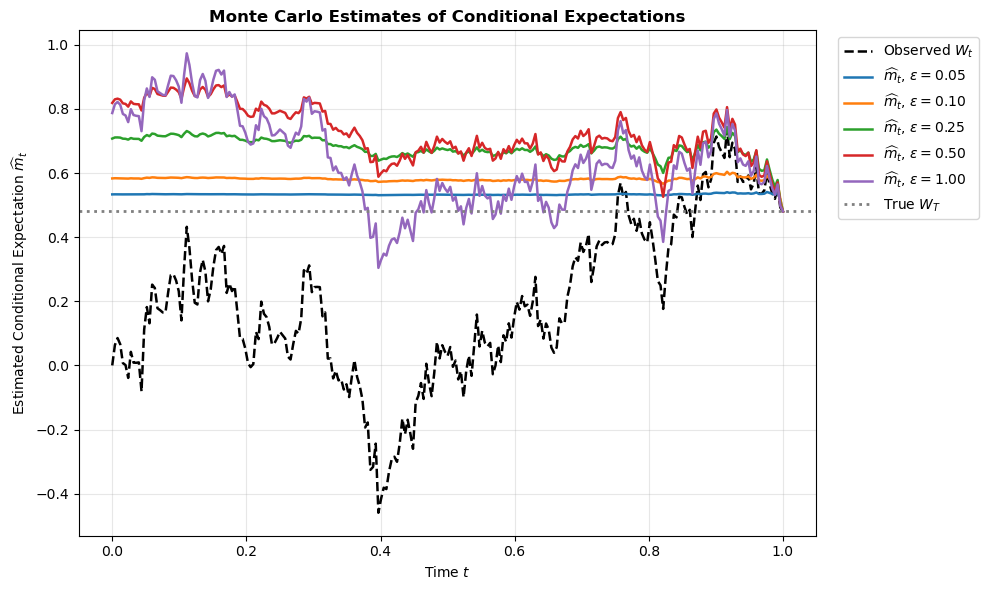


Conditional expectation figure saved as monte_carlo_conditional_expectations.png


In [18]:
# ==================================================
# Plot Monte Carlo conditional expectation estimates
# ==================================================

# Select one path from the testing sample
representative_path = testing_indices[0]

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Observed Brownian motion
ax.plot(
    time_grid,
    brownian_paths[:, representative_path],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label=r"Observed $W_t$"
)

# Estimated conditional expectations
for epsilon in noise_levels:

    ax.plot(
        time_grid,
        conditional_expectation_estimates[
            epsilon
        ][:, representative_path],
        linewidth=1.8,
        label=(
            rf"$\widehat{{m}}_t$, "
            rf"$\varepsilon={epsilon:.2f}$"
        )
    )

# True terminal value
ax.axhline(
    terminal_brownian_values[
        representative_path
    ],
    color="grey",
    linestyle=":",
    linewidth=2,
    label=r"True $W_T$"
)

ax.set_title(
    "Monte Carlo Estimates of Conditional Expectations",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Estimated Conditional Expectation "
    r"$\widehat{m}_t$"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()

conditional_expectation_filename = (
    "monte_carlo_conditional_expectations.png"
)

fig.savefig(
    conditional_expectation_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nConditional expectation figure saved as "
    f"{conditional_expectation_filename}"
)

# Step 5: Computation of the Information Drift

In [26]:
# ==================================================
# Estimation of the information drift
# ==================================================

# The information drift is calculated only for t < T

drift_time_grid = time_grid[:-1]

remaining_time = (
    T - drift_time_grid
)

# Store pathwise estimated and theoretical drifts

estimated_information_drifts = {}
theoretical_information_drifts = {}

# Store time-dependent summary statistics

information_drift_results = []

for epsilon in noise_levels:

    estimated_m = (
        conditional_expectation_estimates[
            epsilon
        ]
    )

    theoretical_m = (
        theoretical_conditional_expectations[
            epsilon
        ]
    )

    # Conditional expectation values on testing paths
    # The terminal observation is excluded

    estimated_m_test = estimated_m[
        :-1,
        testing_indices
    ]

    theoretical_m_test = theoretical_m[
        :-1,
        testing_indices
    ]

    brownian_test = brownian_paths[
        :-1,
        testing_indices
    ]

    signal_test = noisy_signals[
        epsilon
    ][testing_indices]

    # Estimated information drift

    estimated_alpha = (
        estimated_m_test
        - brownian_test
    ) / remaining_time[:, None]

    # Theoretical information drift calculated from m_t

    theoretical_alpha = (
        theoretical_m_test
        - brownian_test
    ) / remaining_time[:, None]

    # Direct theoretical formula

    direct_theoretical_alpha = (
        signal_test[None, :]
        - brownian_test
    ) / (
        remaining_time[:, None]
        + epsilon**2
    )

    # Check that the two theoretical formulas agree

    maximum_formula_difference = np.max(
        np.abs(
            theoretical_alpha
            - direct_theoretical_alpha
        )
    )

    print(
        f"\nMaximum theoretical formula difference "
        f"for epsilon={epsilon:.2f}: "
        f"{maximum_formula_difference:.10f}"
    )

    # Store pathwise results

    estimated_information_drifts[
        epsilon
    ] = estimated_alpha

    theoretical_information_drifts[
        epsilon
    ] = theoretical_alpha

    # Calculate statistics at each observation time

    for time_index, t in enumerate(
        drift_time_grid
    ):

        estimated_values = estimated_alpha[
            time_index,
            :
        ]

        theoretical_values = theoretical_alpha[
            time_index,
            :
        ]

        # Cross-sectional mean of estimated drift

        estimated_mean = np.mean(
            estimated_values
        )

        # Sample mean of the theoretical drift
        # on the same testing paths

        theoretical_sample_mean = np.mean(
            theoretical_values
        )

        # Theoretical population mean

        theoretical_population_mean = 0.0

        # Cross-sectional variance of estimated drift

        estimated_variance = np.var(
            estimated_values,
            ddof=1
        )

        # Sample variance of theoretical drift
        # on the same testing paths

        theoretical_sample_variance = np.var(
            theoretical_values,
            ddof=1
        )

        # Theoretical population variance

        theoretical_population_variance = (
            1
            / (
                T
                - t
                + epsilon**2
            )
        )

        # RMSE between estimated and theoretical drift

        drift_rmse = np.sqrt(
            np.mean(
                (
                    estimated_values
                    - theoretical_values
                ) ** 2
            )
        )

        information_drift_results.append({
            "Time":
                t,
            "Noise level":
                epsilon,
            "Estimated mean":
                estimated_mean,
            "Theoretical sample mean":
                theoretical_sample_mean,
            "Theoretical population mean":
                theoretical_population_mean,
            "Estimated variance":
                estimated_variance,
            "Theoretical sample variance":
                theoretical_sample_variance,
            "Theoretical population variance":
                theoretical_population_variance,
            "Drift RMSE":
                drift_rmse
        })

# Convert the results into a DataFrame

information_drift_results_df = pd.DataFrame(
    information_drift_results
)

print("\nINFORMATION DRIFT ESTIMATION COMPLETED")
print("--------------------------------------")

print(
    f"Number of testing paths: "
    f"{len(testing_indices)}"
)

print(
    f"Number of drift observation times: "
    f"{len(drift_time_grid)}"
)

print(
    f"First drift observation time: "
    f"{drift_time_grid[0]:.6f}"
)

print(
    f"Last drift observation time: "
    f"{drift_time_grid[-1]:.6f}"
)


Maximum theoretical formula difference for epsilon=0.05: 0.0000000000

Maximum theoretical formula difference for epsilon=0.10: 0.0000000000

Maximum theoretical formula difference for epsilon=0.25: 0.0000000000

Maximum theoretical formula difference for epsilon=0.50: 0.0000000000

Maximum theoretical formula difference for epsilon=1.00: 0.0000000000

INFORMATION DRIFT ESTIMATION COMPLETED
--------------------------------------
Number of testing paths: 2000
Number of drift observation times: 252
First drift observation time: 0.000000
Last drift observation time: 0.996032


In [27]:
# ==================================================
# Results at selected observation times
# ==================================================

selected_drift_time_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N),
    int(0.90 * N),
    N - 1
]

selected_drift_times = drift_time_grid[
    selected_drift_time_indices
]

selected_information_drift_results = (
    information_drift_results_df[
        np.isclose(
            information_drift_results_df[
                "Time"
            ].to_numpy()[:, None],
            selected_drift_times,
            atol=1e-10
        ).any(axis=1)
    ]
    .copy()
)

selected_information_drift_results = (
    selected_information_drift_results[
        [
            "Time",
            "Noise level",
            "Estimated mean",
            "Theoretical sample mean",
            "Estimated variance",
            "Theoretical sample variance",
            "Theoretical population variance",
            "Drift RMSE"
        ]
    ]
)

selected_information_drift_results = (
    selected_information_drift_results
    .sort_values(
        [
            "Noise level",
            "Time"
        ]
    )
)

print("\nSELECTED INFORMATION DRIFT RESULTS")
print("----------------------------------")

print(
    selected_information_drift_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

selected_information_drift_results.to_csv(
    "selected_information_drift_results.csv",
    index=False
)

print(
    "\nSelected information drift results saved as "
    "selected_information_drift_results.csv"
)


SELECTED INFORMATION DRIFT RESULTS
----------------------------------
  Time  Noise level  Estimated mean  Theoretical sample mean  Estimated variance  Theoretical sample variance  Theoretical population variance  Drift RMSE
0.0000       0.0500          0.0242                   0.0238              0.9909                       0.9921                           0.9975      0.0007
0.2500       0.0500          0.0244                   0.0239              1.3346                       1.3361                           1.3289      0.0010
0.5000       0.0500          0.0146                   0.0139              1.9916                       1.9925                           1.9900      0.0016
0.7500       0.0500          0.0190                   0.0176              3.9948                       4.0049                           3.9604      0.0033
0.8968       0.0500          0.0506                   0.0476             10.1461                      10.1143                           9.4630      0.0100

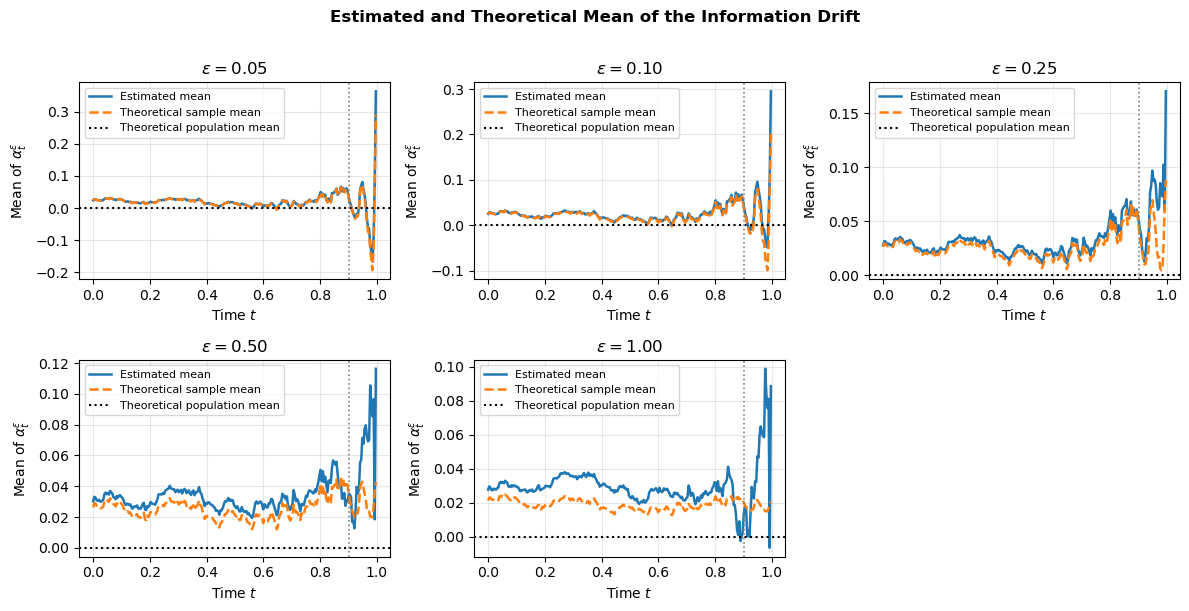


Information drift mean figure saved as information_drift_mean.png


In [32]:
# ==================================================
# Plot the mean of the information drift
# ==================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 6),
    sharex=False
)

axes = axes.flatten()

for plot_index, epsilon in enumerate(
    noise_levels
):

    ax = axes[plot_index]

    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # Mean of estimated drift

    ax.plot(
        epsilon_results["Time"],
        epsilon_results["Estimated mean"],
        color="tab:blue",
        linewidth=1.8,
        label="Estimated mean"
    )

    # Mean of theoretical drift on testing paths

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Theoretical sample mean"
        ],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label="Theoretical sample mean"
    )

    # Theoretical population mean

    ax.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="Theoretical population mean"
    )

    ax.axvline(
        0.9 * T,
        color="grey",
        linestyle=":",
        linewidth=1.2
    )

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    ax.set_xlabel(
        r"Time $t$"
    )

    ax.set_ylabel(
        r"Mean of $\alpha_t^\varepsilon$"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        fontsize=8
    )

# Remove the unused sixth subplot

fig.delaxes(
    axes[-1]
)

fig.suptitle(
    "Estimated and Theoretical Mean "
    "of the Information Drift",
    fontweight="bold",
    y=1.01
)

fig.tight_layout()

drift_mean_filename = (
    "information_drift_mean.png"
)

fig.savefig(
    drift_mean_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift mean figure saved as "
    f"{drift_mean_filename}"
)

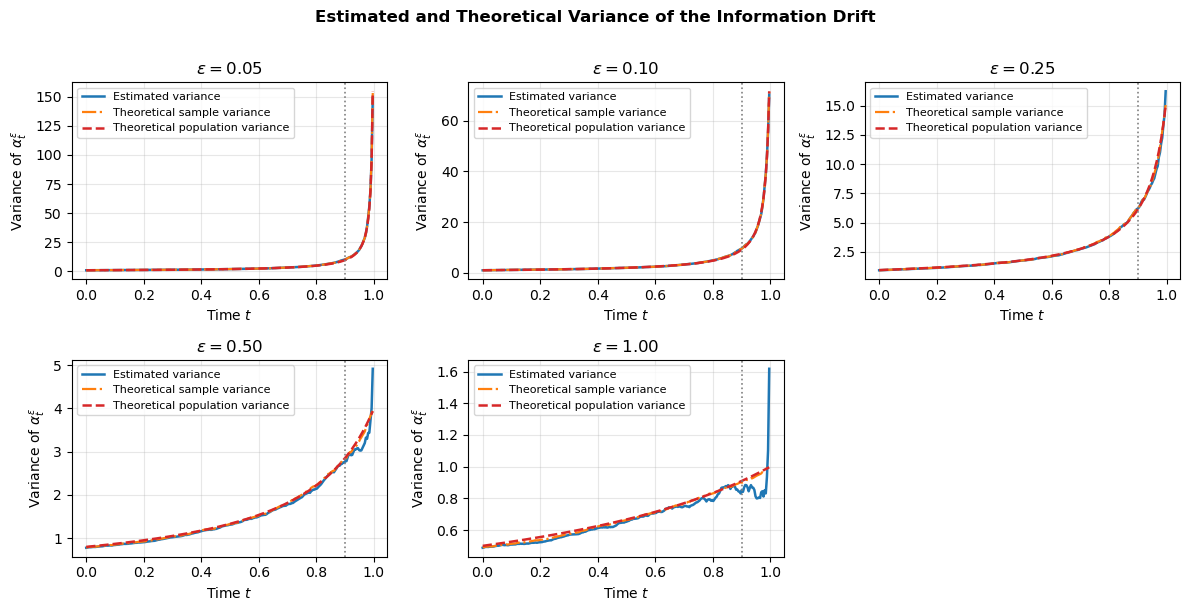


Information drift variance figure saved as information_drift_variance.png


In [33]:
# ==================================================
# Plot the variance of the information drift
# ==================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 6),
    sharex=False
)

axes = axes.flatten()

for plot_index, epsilon in enumerate(
    noise_levels
):

    ax = axes[plot_index]

    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    # Variance of estimated drift

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Estimated variance"
        ],
        color="tab:blue",
        linewidth=1.8,
        label="Estimated variance"
    )

    # Variance of theoretical drift on testing paths

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Theoretical sample variance"
        ],
        color="tab:orange",
        linestyle="-.",
        linewidth=1.6,
        label="Theoretical sample variance"
    )

    # Theoretical population variance

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Theoretical population variance"
        ],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label="Theoretical population variance"
    )

    ax.axvline(
        0.9 * T,
        color="grey",
        linestyle=":",
        linewidth=1.2
    )

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    ax.set_xlabel(
        r"Time $t$"
    )

    ax.set_ylabel(
        r"Variance of $\alpha_t^\varepsilon$"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        fontsize=8
    )

fig.delaxes(
    axes[-1]
)

fig.suptitle(
    "Estimated and Theoretical Variance "
    "of the Information Drift",
    fontweight="bold",
    y=1.01
)

fig.tight_layout()

drift_variance_filename = (
    "information_drift_variance.png"
)

fig.savefig(
    drift_variance_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift variance figure saved as "
    f"{drift_variance_filename}"
)

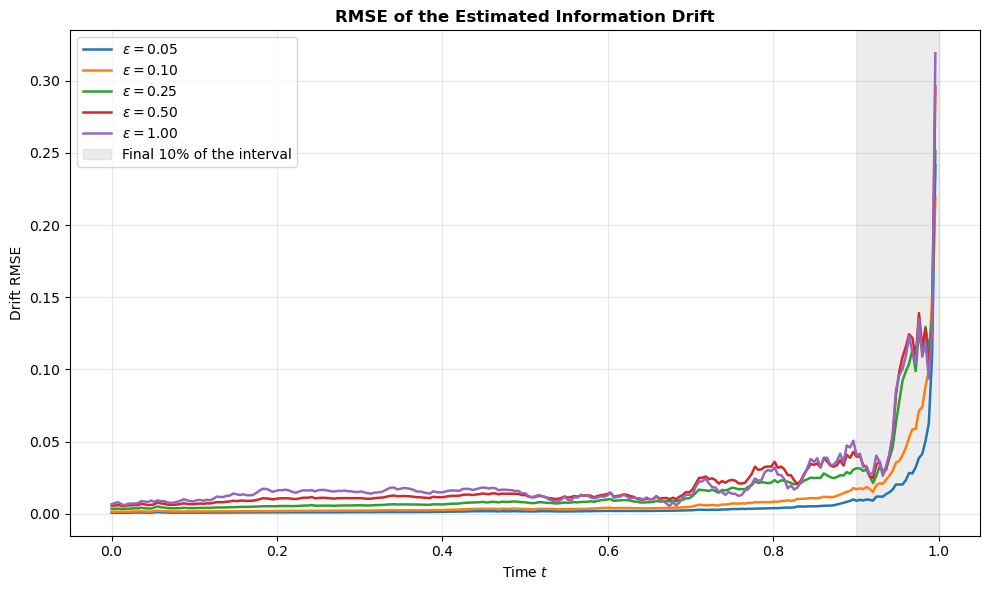


Information drift RMSE figure saved as information_drift_rmse.png


In [34]:
# ==================================================
# Plot drift RMSE over the full interval
# ==================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for epsilon in noise_levels:

    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    ax.plot(
        epsilon_results["Time"],
        epsilon_results["Drift RMSE"],
        linewidth=1.8,
        label=rf"$\varepsilon={epsilon:.2f}$"
    )

ax.axvspan(
    0.9 * T,
    T,
    color="grey",
    alpha=0.15,
    label="Final 10% of the interval"
)

ax.set_title(
    "RMSE of the Estimated Information Drift",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Drift RMSE"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

drift_rmse_filename = (
    "information_drift_rmse.png"
)

fig.savefig(
    drift_rmse_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift RMSE figure saved as "
    f"{drift_rmse_filename}"
)

In [35]:
# ==================================================
# Near-maturity analysis
# ==================================================

near_maturity_mask = (
    information_drift_results_df["Time"]
    >= 0.9 * T
)

near_maturity_results = (
    information_drift_results_df[
        near_maturity_mask
    ]
    .copy()
)

near_maturity_summary = []

for epsilon in noise_levels:

    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    final_result = (
        epsilon_near_results.iloc[-1]
    )

    near_maturity_summary.append({
        "Noise level":
            epsilon,
        "Mean absolute estimated mean":
            np.mean(
                np.abs(
                    epsilon_near_results[
                        "Estimated mean"
                    ]
                )
            ),
        "Estimated mean at final grid point":
            final_result[
                "Estimated mean"
            ],
        "Theoretical sample mean at final grid point":
            final_result[
                "Theoretical sample mean"
            ],
        "Mean near-maturity RMSE":
            epsilon_near_results[
                "Drift RMSE"
            ].mean(),
        "Maximum near-maturity RMSE":
            epsilon_near_results[
                "Drift RMSE"
            ].max(),
        "RMSE at final grid point":
            final_result[
                "Drift RMSE"
            ],
        "Estimated variance at final grid point":
            final_result[
                "Estimated variance"
            ],
        "Theoretical sample variance at final grid point":
            final_result[
                "Theoretical sample variance"
            ],
        "Theoretical population variance at final grid point":
            final_result[
                "Theoretical population variance"
            ]
    })

near_maturity_summary_df = pd.DataFrame(
    near_maturity_summary
)

print("\nNEAR-MATURITY INFORMATION DRIFT SUMMARY")
print("---------------------------------------")

print(
    near_maturity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

near_maturity_summary_df.to_csv(
    "near_maturity_information_drift_summary.csv",
    index=False
)

print(
    "\nNear-maturity summary saved as "
    "near_maturity_information_drift_summary.csv"
)


NEAR-MATURITY INFORMATION DRIFT SUMMARY
---------------------------------------
 Noise level  Mean absolute estimated mean  Estimated mean at final grid point  Theoretical sample mean at final grid point  Mean near-maturity RMSE  Maximum near-maturity RMSE  RMSE at final grid point  Estimated variance at final grid point  Theoretical sample variance at final grid point  Theoretical population variance at final grid point
      0.0500                        0.0645                              0.3636                                       0.2903                   0.0342                      0.2414                    0.2414                                148.6905                                         153.0962                                             154.6012
      0.1000                        0.0463                              0.2951                                       0.2058                   0.0510                      0.2188                    0.2188                           

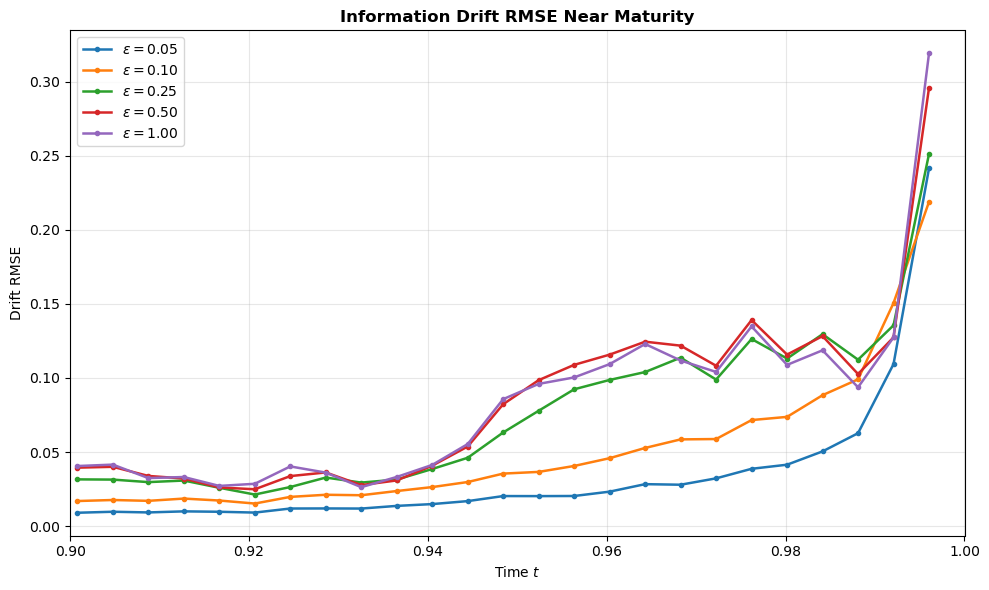


Near-maturity RMSE figure saved as information_drift_near_maturity_rmse.png


In [36]:
# ==================================================
# Plot near-maturity drift RMSE
# ==================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for epsilon in noise_levels:

    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    ax.plot(
        epsilon_near_results["Time"],
        epsilon_near_results["Drift RMSE"],
        linewidth=1.8,
        marker="o",
        markersize=3,
        label=rf"$\varepsilon={epsilon:.2f}$"
    )

ax.set_title(
    "Information Drift RMSE Near Maturity",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Drift RMSE"
)

ax.set_xlim(
    0.9 * T,
    T
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

near_maturity_rmse_filename = (
    "information_drift_near_maturity_rmse.png"
)

fig.savefig(
    near_maturity_rmse_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nNear-maturity RMSE figure saved as "
    f"{near_maturity_rmse_filename}"
)

# Step 5: Computation of the Information Drift（mean没写齐

In [20]:
# ==================================================
# Estimation of the information drift
# ==================================================

# Store pathwise estimated and theoretical drifts

estimated_information_drifts = {}
theoretical_information_drifts = {}

# Store time-dependent summary statistics

information_drift_results = []

# The drift is calculated only for t < T

drift_time_grid = time_grid[:-1]
remaining_time = T - drift_time_grid

for epsilon in noise_levels:

    estimated_m = (
        conditional_expectation_estimates[
            epsilon
        ]
    )

    theoretical_m = (
        theoretical_conditional_expectations[
            epsilon
        ]
    )

    # Use only testing paths and exclude t = T

    estimated_m_test = estimated_m[
        :-1,
        testing_indices
    ]

    theoretical_m_test = theoretical_m[
        :-1,
        testing_indices
    ]

    brownian_test = brownian_paths[
        :-1,
        testing_indices
    ]

    # Estimated information drift

    estimated_alpha = (
        estimated_m_test
        - brownian_test
    ) / remaining_time[:, None]

    # Theoretical information drift obtained from m_t

    theoretical_alpha = (
        theoretical_m_test
        - brownian_test
    ) / remaining_time[:, None]

    # Equivalent direct theoretical formula

    direct_theoretical_alpha = (
        noisy_signals[epsilon][
            testing_indices
        ][None, :]
        - brownian_test
    ) / (
        remaining_time[:, None]
        + epsilon**2
    )

    # Check that the two theoretical formulas agree

    maximum_formula_difference = np.max(
        np.abs(
            theoretical_alpha
            - direct_theoretical_alpha
        )
    )

    print(
        f"\nMaximum theoretical formula difference "
        f"for epsilon={epsilon:.2f}: "
        f"{maximum_formula_difference:.10f}"
    )

    estimated_information_drifts[
        epsilon
    ] = estimated_alpha

    theoretical_information_drifts[
        epsilon
    ] = theoretical_alpha

    # Calculate statistics at every observation time

    for time_index, t in enumerate(
        drift_time_grid
    ):

        estimated_values = estimated_alpha[
            time_index,
            :
        ]

        theoretical_values = theoretical_alpha[
            time_index,
            :
        ]

        drift_rmse = np.sqrt(
            np.mean(
                (
                    estimated_values
                    - theoretical_values
                ) ** 2
            )
        )

        estimated_mean = np.mean(
            estimated_values
        )

        theoretical_mean = np.mean(
            theoretical_values
        )

        estimated_variance = np.var(
            estimated_values,
            ddof=1
        )

        theoretical_sample_variance = np.var(
            theoretical_values,
            ddof=1
        )

        # Population variance implied by the model

        theoretical_population_variance = (
            1
            / (
                T
                - t
                + epsilon**2
            )
        )

        information_drift_results.append({
            "Time": t,
            "Noise level": epsilon,
            "Estimated mean":
                estimated_mean,
            "Theoretical sample mean":
                theoretical_mean,
            "Estimated variance":
                estimated_variance,
            "Theoretical sample variance":
                theoretical_sample_variance,
            "Theoretical population variance":
                theoretical_population_variance,
            "Drift RMSE":
                drift_rmse
        })

information_drift_results_df = pd.DataFrame(
    information_drift_results
)

print("\nINFORMATION DRIFT ESTIMATION COMPLETED")
print("--------------------------------------")
print(
    f"Number of testing paths: "
    f"{len(testing_indices)}"
)
print(
    f"Number of drift observation times: "
    f"{len(drift_time_grid)}"
)
print(
    f"Last drift observation time: "
    f"{drift_time_grid[-1]:.6f}"
)


Maximum theoretical formula difference for epsilon=0.05: 0.0000000000

Maximum theoretical formula difference for epsilon=0.10: 0.0000000000

Maximum theoretical formula difference for epsilon=0.25: 0.0000000000

Maximum theoretical formula difference for epsilon=0.50: 0.0000000000

Maximum theoretical formula difference for epsilon=1.00: 0.0000000000

INFORMATION DRIFT ESTIMATION COMPLETED
--------------------------------------
Number of testing paths: 2000
Number of drift observation times: 252
Last drift observation time: 0.996032


In [21]:
# ==================================================
# Results at selected observation times
# ==================================================

selected_drift_time_indices = [
    0,
    int(0.25 * N),
    int(0.50 * N),
    int(0.75 * N),
    int(0.90 * N),
    N - 1
]

selected_drift_times = drift_time_grid[
    selected_drift_time_indices
]

selected_information_drift_results = (
    information_drift_results_df[
        np.isclose(
            information_drift_results_df[
                "Time"
            ].to_numpy()[:, None],
            selected_drift_times,
            atol=1e-10
        ).any(axis=1)
    ]
    .copy()
)

selected_information_drift_results = (
    selected_information_drift_results[
        [
            "Time",
            "Noise level",
            "Estimated mean",
            "Estimated variance",
            "Theoretical population variance",
            "Drift RMSE"
        ]
    ]
)

print("\nSELECTED INFORMATION DRIFT RESULTS")
print("----------------------------------")

print(
    selected_information_drift_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


SELECTED INFORMATION DRIFT RESULTS
----------------------------------
  Time  Noise level  Estimated mean  Estimated variance  Theoretical population variance  Drift RMSE
0.0000       0.0500          0.0242              0.9909                           0.9975      0.0007
0.2500       0.0500          0.0244              1.3346                           1.3289      0.0010
0.5000       0.0500          0.0146              1.9916                           1.9900      0.0016
0.7500       0.0500          0.0190              3.9948                           3.9604      0.0033
0.8968       0.0500          0.0506             10.1461                           9.4630      0.0100
0.9960       0.0500          0.3636            148.6905                         154.6012      0.2414
0.0000       0.1000          0.0254              0.9807                           0.9901      0.0014
0.2500       0.1000          0.0262              1.3147                           1.3158      0.0021
0.5000       0.1000 

In [22]:
# ==================================================
# Near-maturity analysis
# ==================================================

near_maturity_mask = (
    information_drift_results_df["Time"]
    >= 0.9 * T
)

near_maturity_results = (
    information_drift_results_df[
        near_maturity_mask
    ]
    .copy()
)

near_maturity_summary = []

for epsilon in noise_levels:

    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    final_result = (
        epsilon_near_results.iloc[-1]
    )

    near_maturity_summary.append({
        "Noise level": epsilon,
        "Mean near-maturity RMSE":
            epsilon_near_results[
                "Drift RMSE"
            ].mean(),
        "Maximum near-maturity RMSE":
            epsilon_near_results[
                "Drift RMSE"
            ].max(),
        "RMSE at final grid point":
            final_result["Drift RMSE"],
        "Estimated variance at final grid point":
            final_result["Estimated variance"],
        "Theoretical variance at final grid point":
            final_result[
                "Theoretical population variance"
            ]
    })

near_maturity_summary_df = pd.DataFrame(
    near_maturity_summary
)

print("\nNEAR-MATURITY INFORMATION DRIFT SUMMARY")
print("---------------------------------------")

print(
    near_maturity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


NEAR-MATURITY INFORMATION DRIFT SUMMARY
---------------------------------------
 Noise level  Mean near-maturity RMSE  Maximum near-maturity RMSE  RMSE at final grid point  Estimated variance at final grid point  Theoretical variance at final grid point
      0.0500                   0.0342                      0.2414                    0.2414                                148.6905                                  154.6012
      0.1000                   0.0510                      0.2188                    0.2188                                 70.2694                                   71.5909
      0.2500                   0.0756                      0.2512                    0.2512                                 16.2312                                   15.0448
      0.5000                   0.0835                      0.2958                    0.2958                                  4.9182                                    3.9375
      1.0000                   0.0827            

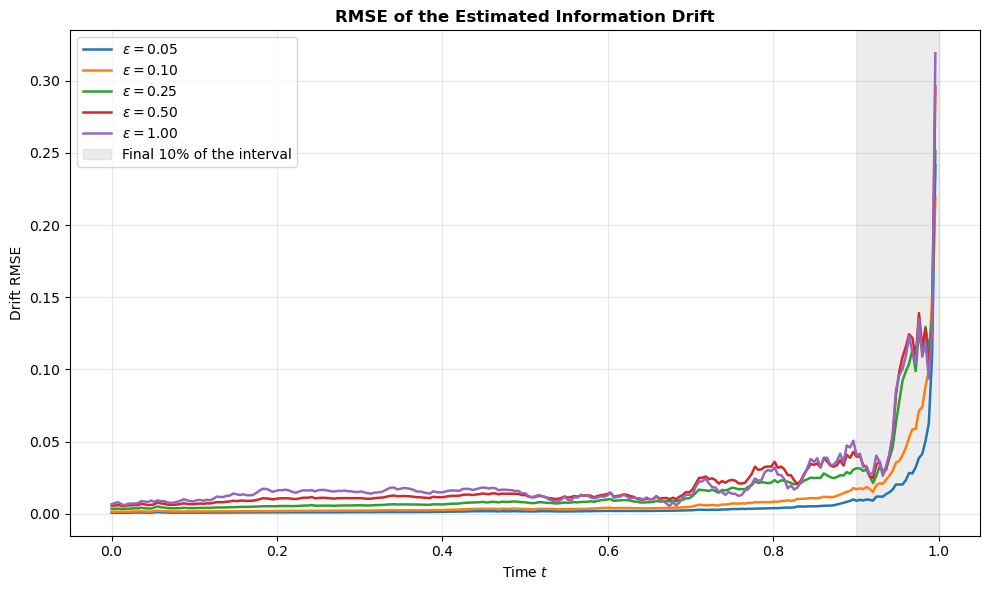


Information drift RMSE figure saved as information_drift_rmse.png


In [23]:
# ==================================================
# Plot drift estimation RMSE over the full interval
# ==================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for epsilon in noise_levels:

    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    ax.plot(
        epsilon_results["Time"],
        epsilon_results["Drift RMSE"],
        linewidth=1.8,
        label=rf"$\varepsilon={epsilon:.2f}$"
    )

ax.axvspan(
    0.9 * T,
    T,
    color="grey",
    alpha=0.15,
    label="Final 10% of the interval"
)

ax.set_title(
    "RMSE of the Estimated Information Drift",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Drift RMSE"
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

drift_rmse_filename = (
    "information_drift_rmse.png"
)

fig.savefig(
    drift_rmse_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift RMSE figure saved as "
    f"{drift_rmse_filename}"
)

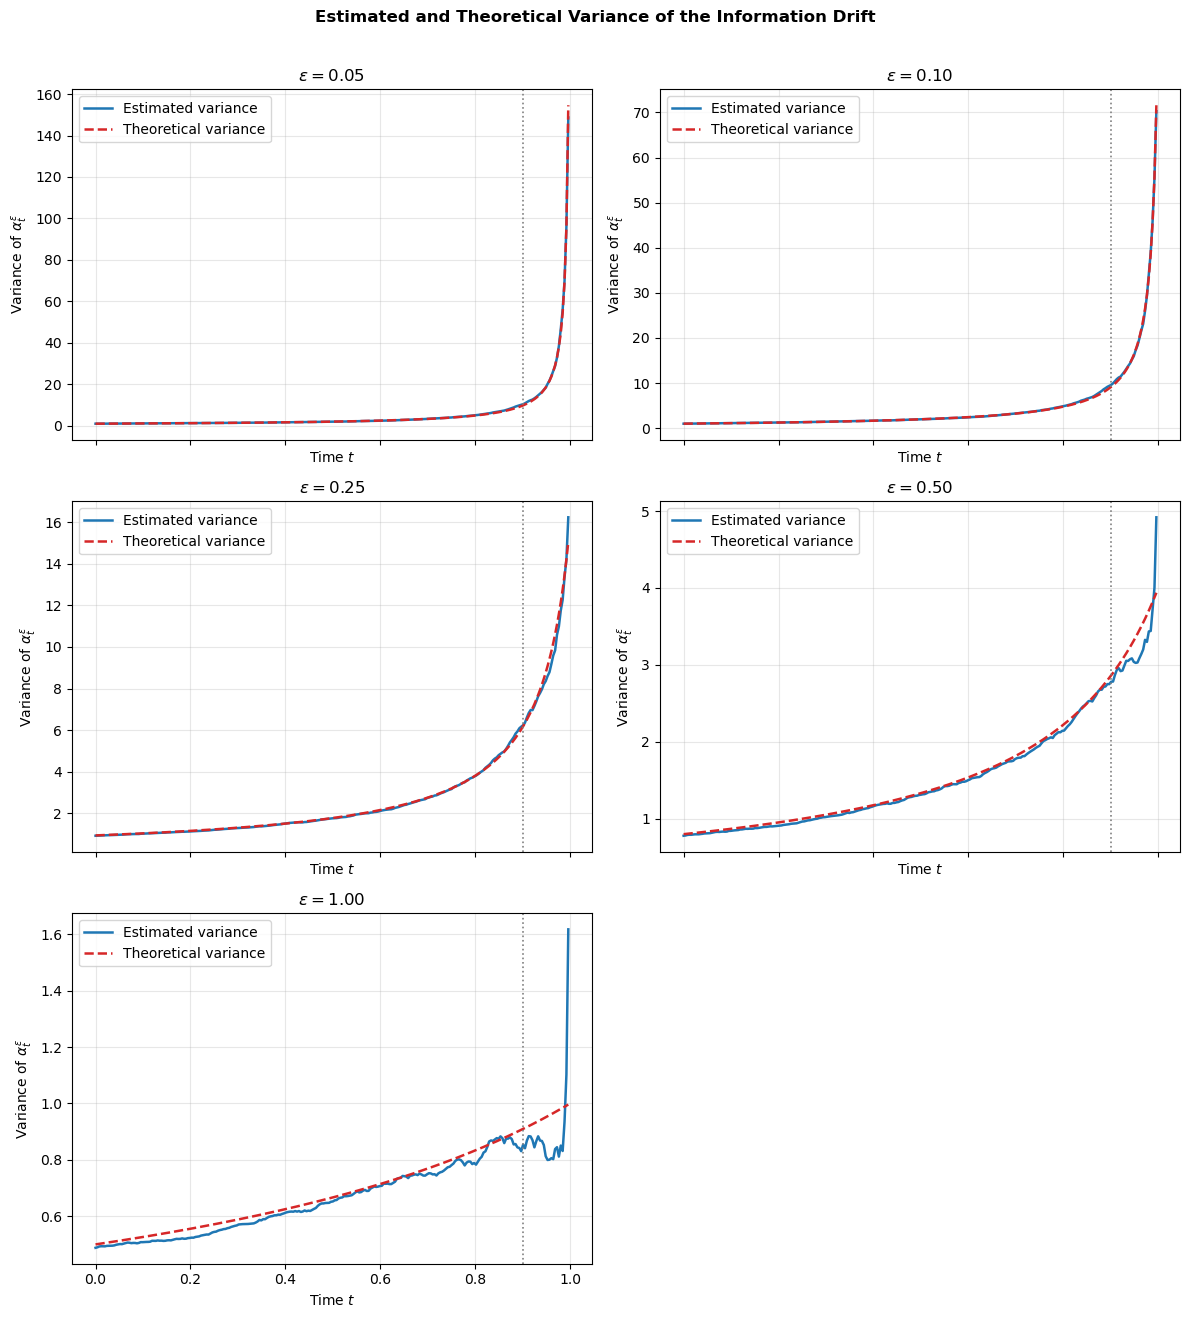


Information drift variance figure saved as information_drift_variance.png


In [24]:
# ==================================================
# Plot estimated and theoretical drift variance
# ==================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 13),
    sharex=True
)

axes = axes.flatten()

for plot_index, epsilon in enumerate(
    noise_levels
):

    ax = axes[plot_index]

    epsilon_results = (
        information_drift_results_df[
            np.isclose(
                information_drift_results_df[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Estimated variance"
        ],
        color="tab:blue",
        linewidth=1.8,
        label="Estimated variance"
    )

    ax.plot(
        epsilon_results["Time"],
        epsilon_results[
            "Theoretical population variance"
        ],
        color="tab:red",
        linestyle="--",
        linewidth=1.8,
        label="Theoretical variance"
    )

    ax.axvline(
        0.9 * T,
        color="grey",
        linestyle=":",
        linewidth=1.2
    )

    ax.set_title(
        rf"$\varepsilon={epsilon:.2f}$",
        fontweight="bold"
    )

    ax.set_xlabel(
        r"Time $t$"
    )

    ax.set_ylabel(
        r"Variance of $\alpha_t^\varepsilon$"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

# Remove the unused sixth subplot

fig.delaxes(
    axes[-1]
)

fig.suptitle(
    "Estimated and Theoretical Variance "
    "of the Information Drift",
    fontweight="bold",
    y=1.01
)

fig.tight_layout()

drift_variance_filename = (
    "information_drift_variance.png"
)

fig.savefig(
    drift_variance_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nInformation drift variance figure saved as "
    f"{drift_variance_filename}"
)

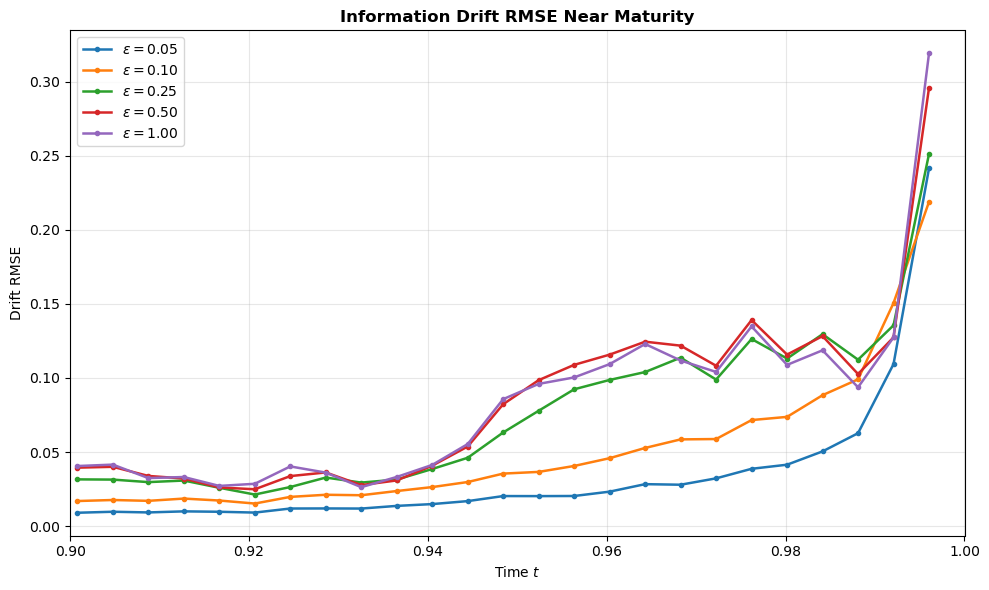


Near-maturity figure saved as information_drift_near_maturity.png


In [25]:
# ==================================================
# Plot near-maturity drift RMSE
# ==================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for epsilon in noise_levels:

    epsilon_near_results = (
        near_maturity_results[
            np.isclose(
                near_maturity_results[
                    "Noise level"
                ],
                epsilon
            )
        ]
        .sort_values("Time")
    )

    ax.plot(
        epsilon_near_results["Time"],
        epsilon_near_results["Drift RMSE"],
        linewidth=1.8,
        marker="o",
        markersize=3,
        label=rf"$\varepsilon={epsilon:.2f}$"
    )

ax.set_title(
    "Information Drift RMSE Near Maturity",
    fontweight="bold"
)

ax.set_xlabel(
    r"Time $t$"
)

ax.set_ylabel(
    r"Drift RMSE"
)

ax.set_xlim(
    0.9 * T,
    T
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

near_maturity_filename = (
    "information_drift_near_maturity.png"
)

fig.savefig(
    near_maturity_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nNear-maturity figure saved as "
    f"{near_maturity_filename}"
)

# Step 6: Measuring the Strength of the Enlargement